# Classify and Caption Images Using Pretrained Models

Final project of [Introduction to Deep Learning & Neural Networks with Keras](https://www.coursera.org/learn/introduction-to-deep-learning-with-keras/home/welcome)

In this project, I classify images of aircraft damage as "dent" or "crack" using a pretrained VGG16 model. I also generate captions and summaries using a pretrained Transformer-based model.

This uses the [Aircraft dataset](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/ZjXM4RKxlBK9__ZjHBLl5A/aircraft-damage-dataset-v1.tar).
The dataset is taken from [Roboflow Aircraft Dataset](https://universe.roboflow.com/youssef-donia-fhktl/aircraft-damage-detection-1j9qk) Provided by a Roboflow user, License: CC BY 4.


## Dataset Preparation


In [1]:
import warnings
warnings.filterwarnings('ignore')

### Install Required Libraries


In [ ]:
!pip install pandas==2.2.3
!pip install tensorflow==2.17.1
!pip install pillow==11.1.0
!pip install matplotlib==3.9.2
!pip install transformers==4.38.2
!pip install torch

In [2]:
# Suppress the tensorflow warning messages due to use of CPU architechture for tensorflow
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

### Import Required Libraries


In [56]:
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, Flatten, Layer
from keras.applications import VGG16
from keras.optimizers import Adam
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import random
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration

In [5]:
# Set seed for reproducibility
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

## Classify image of defect on an aircraft as 'dent' or 'crack'

### Dataset Preparation


In [6]:
# Define model configuration options
batch_size = 32
n_epochs = 5
img_rows, img_cols = 224, 224
input_shape = (img_rows, img_cols, 3)

Download the dataset and unzip it to the current directory. It contains directories for train, test, and validation splits.


In [ ]:
import tarfile
import urllib.request
import os
import shutil

# URL of the tar file
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/ZjXM4RKxlBK9__ZjHBLl5A/aircraft-damage-dataset-v1.tar"

# Define the path to save the file
tar_filename = "aircraft_damage_dataset_v1.tar"
extracted_folder = "aircraft_damage_dataset_v1"  # Folder where contents will be extracted

# Download the tar file
urllib.request.urlretrieve(url, tar_filename)
print(f"Downloaded {tar_filename}. Extraction will begin now.")

# Check if the folder already exists
if os.path.exists(extracted_folder):
    print(f"The folder '{extracted_folder}' already exists. Removing the existing folder.")
    
    # Remove the existing folder to avoid overwriting or duplication
    shutil.rmtree(extracted_folder)
    print(f"Removed the existing folder: {extracted_folder}")

# Extract the contents of the tar file
with tarfile.open(tar_filename, "r") as tar_ref:
    tar_ref.extractall()  # This will extract to the current directory
    print(f"Extracted {tar_filename} successfully.")

Downloaded aircraft_damage_dataset_v1.tar. Extraction will begin now.
Extracted aircraft_damage_dataset_v1.tar successfully.


The folder structure looks as follows:

```python
aircraft_damage_dataset_v1/
├── train/
│   ├── dent/
│   └── crack/
├── valid/
│   ├── dent/
│   └── crack/
└── test/
    ├── dent/
    └── crack/

```



In [7]:
# Define directories for train, test, and validation splits
extract_path = "aircraft_damage_dataset_v1"
train_dir = os.path.join(extract_path, 'train')
test_dir = os.path.join(extract_path, 'test')
valid_dir = os.path.join(extract_path, 'valid')

### Data Preprocessing


In [8]:
# Create ImageDataGenerators to preprocess the data
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
# Load images from directory to generate the train dataset
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_rows, img_cols),   # Resize images to the size VGG16 expects
    class_mode='binary',  # Binary classification: dent vs crack
    batch_size=batch_size,
    shuffle=True
    seed=seed_value,
)

Found 300 images belonging to 2 classes.


In [ ]:
# Load images from directory to generate the validation dataset
valid_generator = valid_datagen.flow_from_directory(
    directory=valid_dir,
    target_size=(img_rows, img_cols),
    class_mode='binary',
    batch_size=batch_size,
    shuffle=False,
    seed=seed_value,
)

Found 96 images belonging to 2 classes.


In [53]:
# Load images from directory to generate the test dataset
test_generator = test_datagen.flow_from_directory(
    directory=test_dir,
    target_size=(img_rows, img_cols),
    class_mode='binary',
    batch_size=batch_size,
    shuffle=False,
    seed=seed_value,
)

Found 50 images belonging to 2 classes.


### Model Definition


Load pretrained VGG16 model

In [ ]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)

Modify VGG16 model for this classification task

In [15]:
# Extract output from last layer of pretrained VGG16 model and create a new model with this modified output
output = base_model.layers[-1].output
output = Flatten()(output)
base_model = Model(base_model.input, output)

# Freeze base VGG16 model layers so their weights will not be updated during training
for layer in base_model.layers:
    layer.trainable = False

After using VGG16 as a feature extractor, add a custom classifier on top of that. This involves adding fully connected layers (Dense), activation functions, dropout layers to avoid overfitting, and a sigmoid activation to output the probability for binary classification ("dent" vs "crack").


In [16]:
# Build the custom model
model = Sequential()
model.add(base_model)
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

### Model Compilation


In [18]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

### Model Training


In [19]:
history = model.fit(
    train_generator,
    epochs=n_epochs,
    validation_data=valid_generator,   
)

Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.5367 - loss: 0.7201 - val_accuracy: 0.6042 - val_loss: 0.6338
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.7233 - loss: 0.5535 - val_accuracy: 0.6979 - val_loss: 0.5821
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.7767 - loss: 0.4737 - val_accuracy: 0.7188 - val_loss: 0.5486
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.8133 - loss: 0.4123 - val_accuracy: 0.6562 - val_loss: 0.6457
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.8800 - loss: 0.3204 - val_accuracy: 0.7083 - val_loss: 0.5098


In [20]:
# Access the training history
train_history = model.history.history

### Visualize Training Results

After training the model, visualize the training and validation accuracy and loss to understand the model's learning process.


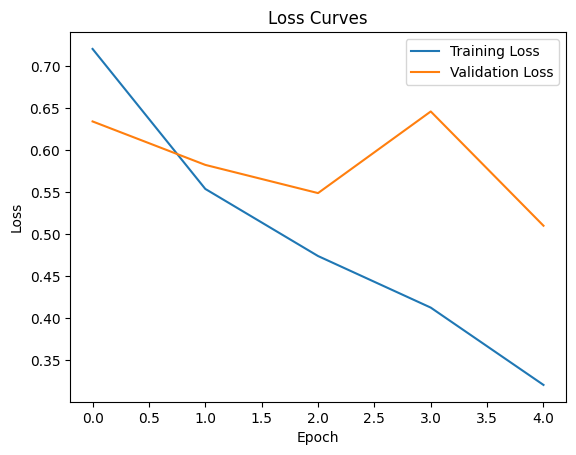

In [27]:
# Plot the loss curves for both training and validation
plt.title("Loss Curves")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.plot(train_history['loss'], label="Training Loss")
plt.plot(train_history['val_loss'], label="Validation Loss")
plt.legend()

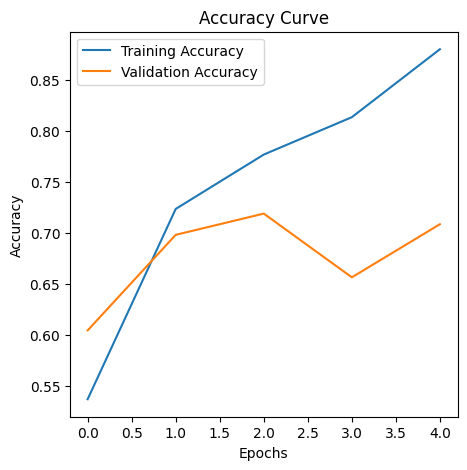

In [28]:
# Plot accuracy curves for training and validation sets
plt.figure(figsize=(5, 5))
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.plot(train_history['accuracy'], label="Training Accuracy")
plt.plot(train_history['val_accuracy'], label="Validation Accuracy")
plt.legend()

### Model Evaluation

Evaluate the trained model on the test dataset. Calculate test loss and accuracy by evaluating the test generator. Predictions are made for the test dataset, and the results are compared to true labels.


In [54]:
test_loss, test_accuracy = model.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.6875 - loss: 0.7326
Test Loss: 0.7326
Test Accuracy: 0.6875


### Visualize Predictions

Display test images alongside their true and predicted labels, for visual inspection of model performance.


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


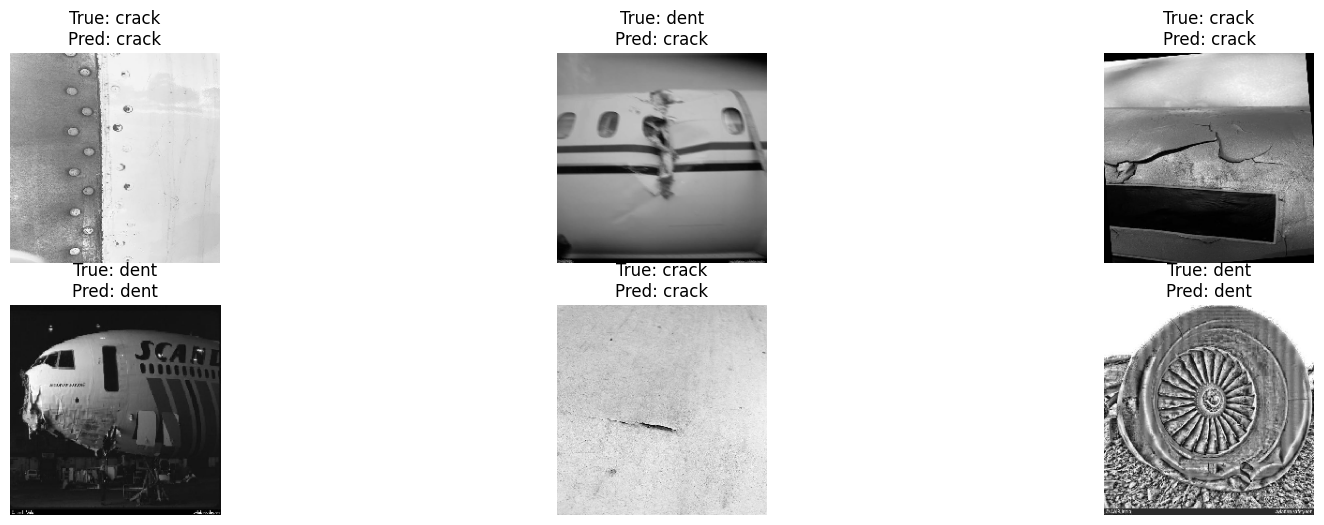

In [ ]:
# Function to plot a single image and its prediction
def plot_image_with_title(image, true_label, predicted_label, class_names, plot_index):
    plt.subplot(2, 3, plot_index + 1)
    plt.imshow(image)

    # Convert labels from one-hot to class indices if needed, but for binary labels it's just 0 or 1
    true_label_name = class_names[true_label]  # Labels are already in class indices
    pred_label_name = class_names[predicted_label]  # Predictions are 0 or 1

    plt.title(f"True: {true_label_name}\nPred: {pred_label_name}")
    plt.axis('off')

# Function to test the model with images from the test set
def test_model_on_image(test_generator, model, index_to_plot=0):
    # Get a batch of images and labels from the test generator
    test_images, test_labels = next(test_generator)

    # Make predictions on the batch
    predictions = model.predict(test_images)

    # In binary classification, predictions are probabilities (float). Convert to binary (0 or 1)
    predicted_classes = (predictions > 0.5).astype(int).flatten()

    # Get the class indices from the test generator and invert them to get class names
    class_indices = test_generator.class_indices
    class_names = {v: k for k, v in class_indices.items()}  # Invert the dictionary

    # Specify the image to display based on the index
    image_to_plot = test_images[index_to_plot]
    true_label = test_labels[index_to_plot]
    predicted_label = predicted_classes[index_to_plot]

    # Plot the selected image with its true and predicted labels
    plot_image_with_title(image=image_to_plot, true_label=true_label, predicted_label=predicted_label, class_names=class_names, plot_index=index_to_plot)

plt.figure(figsize=(20, 6))

for i in range(6):
    test_model_on_image(test_generator, model, index_to_plot=i)

## Caption and summarise image using pretrained BLIP model


### Load BLIP Model and Processor from Hugging Face


In [57]:
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

### Create custom Keras layer

Create custom Keras layer to generate a caption or summary using the BLIP model.

In [59]:
class BlipCaptionSummaryLayer(Layer):
    def __init__(self, processor, model, **kwargs):
        """
        Initialize the custom Keras layer with the BLIP processor and model.

        Args:
            processor: The BLIP processor for preparing inputs for the model.
            model: The BLIP model for generating captions or summaries.
        """
        super().__init__(**kwargs)
        self.processor = processor
        self.model = model

    def call(self, image_path, task):
        """ Defines the operations or transformations applied to the input data as it passes through the layer """
        return tf.py_function(self.process_image, [image_path, task], tf.string)

    def process_image(self, image_path, task):
        """
        Perform image loading, preprocessing, and text generation.

        Args:
            image_path: Path to the image file as a string.
            task: The type of task ("caption" or "summary").

        Returns:
            The generated caption or summary as a string.
        """
        try:
            # Decode the image path from the TensorFlow tensor to a Python string
            image_path_str = image_path.numpy().decode("utf-8")

            # Open the image using PIL and convert it to RGB format
            image = Image.open(image_path_str).convert("RGB")

            # Set the appropriate prompt based on the task
            if task.numpy().decode("utf-8") == "caption":
                prompt = "This is a picture of"  # Modify prompt for more natural output
            else:
                prompt = "This is a detailed photo showing"  # Modify for summary

            # Prepare inputs for the BLIP model
            inputs = self.processor(images=image, text=prompt, return_tensors="pt")

            # Generate text output using the BLIP model
            output = self.model.generate(**inputs)

            # Decode the output into a readable string
            result = self.processor.decode(output[0], skip_special_tokens=True)
            return result
        except Exception as e:
            # Handle errors during image processing or text generation
            print(f"Error: {e}")
            return "Error processing image"

# Helper function to use the custom layer
def generate_text(image_path, task):
    blip_layer = BlipCaptionSummaryLayer(processor, model)
    return blip_layer(image_path, task)

### Generating Captions and Summaries


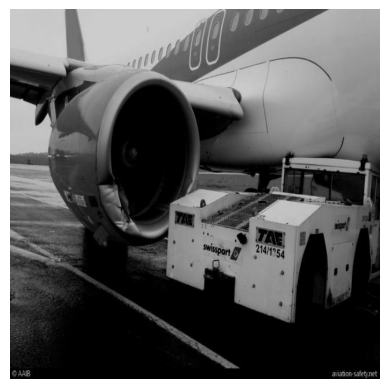

Caption: this is a picture of a plane
Summary: this is a detailed photo showing the engine of a boeing 747


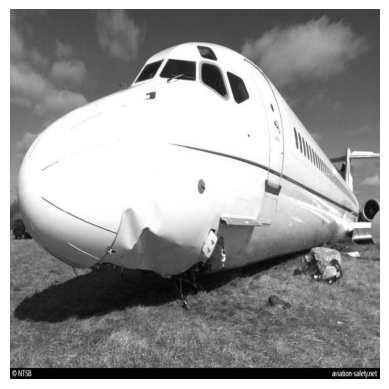

Caption: this is a picture of a plane that was sitting on the ground in a field
Summary: this is a detailed photo showing the damage to the fuselage of the aircraft


In [ ]:
for image_url in [
    "aircraft_damage_dataset_v1/test/dent/144_10_JPG_jpg.rf.4d008cc33e217c1606b76585469d626b.jpg",
    "aircraft_damage_dataset_v1/test/dent/149_22_JPG_jpg.rf.4899cbb6f4aad9588fa3811bb886c34d.jpg",
]:
    image_path = tf.constant(image_url)

    plt.imshow(plt.imread(image_url))
    plt.axis('off')
    plt.show()

    caption = generate_text(image_path, tf.constant("caption"))
    print("Caption:", caption.numpy().decode("utf-8"))

    summary = generate_text(image_path, tf.constant("summary"))
    print("Summary:", summary.numpy().decode("utf-8"))